In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings("ignore")

# Load Boston Housing dataset
url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
df = pd.read_csv(url)

X = df.drop("medv", axis=1)
y = df["medv"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42
)

print("Training Set:", X_train.shape)
print("Testing Set :", X_test.shape)


Training Set: (404, 13)
Testing Set : (102, 13)


In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Train model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Prediction
lr_preds = lr_model.predict(X_test)

# Metrics
lr_r2 = r2_score(y_test, lr_preds)
lr_mae = mean_absolute_error(y_test, lr_preds)
lr_mse = mean_squared_error(y_test, lr_preds)
lr_rmse = np.sqrt(lr_mse)

print("----- Linear Regression -----")
print(f"R2 Score : {lr_r2:.4f}")
print(f"Accuracy : {lr_r2*100:.2f}%")
print(f"MAE      : {lr_mae:.4f}")
print(f"MSE      : {lr_mse:.4f}")
print(f"RMSE     : {lr_rmse:.4f}")

----- Linear Regression -----
R2 Score : 0.6688
Accuracy : 66.88%
MAE      : 3.1891
MSE      : 24.2911
RMSE     : 4.9286


In [5]:
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Train model
svr_model = SVR(kernel='rbf')
svr_model.fit(X_train, y_train)

# Prediction
svr_preds = svr_model.predict(X_test)

# Metrics
svr_r2 = r2_score(y_test, svr_preds)
svr_mae = mean_absolute_error(y_test, svr_preds)
svr_mse = mean_squared_error(y_test, svr_preds)
svr_rmse = np.sqrt(svr_mse)

print("----- Support Vector Regression -----")
print(f"R2 Score : {svr_r2:.4f}")
print(f"Accuracy : {svr_r2*100:.2f}%")
print(f"MAE      : {svr_mae:.4f}")
print(f"MSE      : {svr_mse:.4f}")
print(f"RMSE     : {svr_rmse:.4f}")


----- Support Vector Regression -----
R2 Score : 0.6496
Accuracy : 64.96%
MAE      : 2.7328
MSE      : 25.6930
RMSE     : 5.0688


In [7]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Train model
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

# Prediction
dt_preds = dt_model.predict(X_test)

# Metrics
dt_r2 = r2_score(y_test, dt_preds)
dt_mae = mean_absolute_error(y_test, dt_preds)
dt_mse = mean_squared_error(y_test, dt_preds)
dt_rmse = np.sqrt(dt_mse)

print("----- Decision Tree Regression -----")
print(f"R2 Score : {dt_r2:.4f}")
print(f"Accuracy : {dt_r2*100:.2f}%")
print(f"MAE      : {dt_mae:.4f}")
print(f"MSE      : {dt_mse:.4f}")
print(f"RMSE     : {dt_rmse:.4f}")


----- Decision Tree Regression -----
R2 Score : 0.8580
Accuracy : 85.80%
MAE      : 2.3941
MSE      : 10.4161
RMSE     : 3.2274


In [8]:

import pandas as pd

comparison_df = pd.DataFrame({
    "Regression Algorithm": [
        "Linear Regression",
        "Support Vector Regression",
        "Decision Tree Regression"
    ],
    "R2 Score (%)": [
        lr_r2 * 100,
        svr_r2 * 100,
        dt_r2 * 100
    ],
    "MAE": [
        lr_mae,
        svr_mae,
        dt_mae
    ],
    "MSE": [
        lr_mse,
        svr_mse,
        dt_mse
    ],
    "RMSE": [
        lr_rmse,
        svr_rmse,
        dt_rmse
    ]
})

print("\n----- Regression Performance Comparison -----")
print(comparison_df.to_string(index=False))



----- Regression Performance Comparison -----
     Regression Algorithm  R2 Score (%)      MAE       MSE     RMSE
        Linear Regression     66.875949 3.189092 24.291119 4.928602
Support Vector Regression     64.964256 2.732769 25.693037 5.068830
 Decision Tree Regression     85.796344 2.394118 10.416078 3.227395


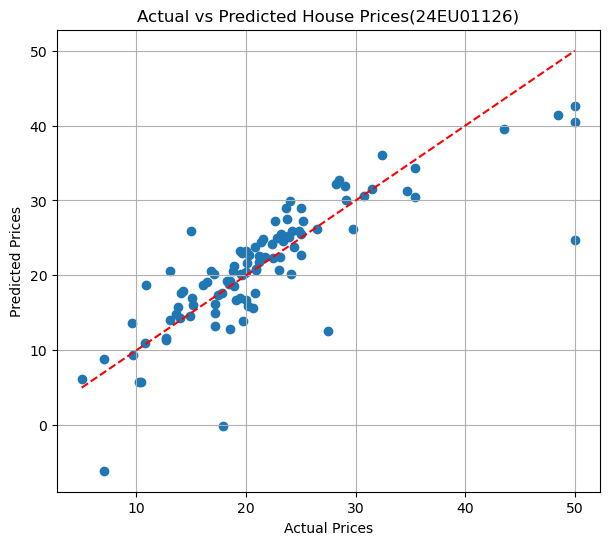

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
df = pd.read_csv(url)

X = df.drop("medv", axis=1)
y = df["medv"]

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

model=LinearRegression()
model.fit(X_train,y_train)

pred=model.predict(X_test)

plt.figure(figsize=(7,6))
plt.scatter(y_test,pred)
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],'r--')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices(24EU01126)")
plt.grid(True)
plt.show()

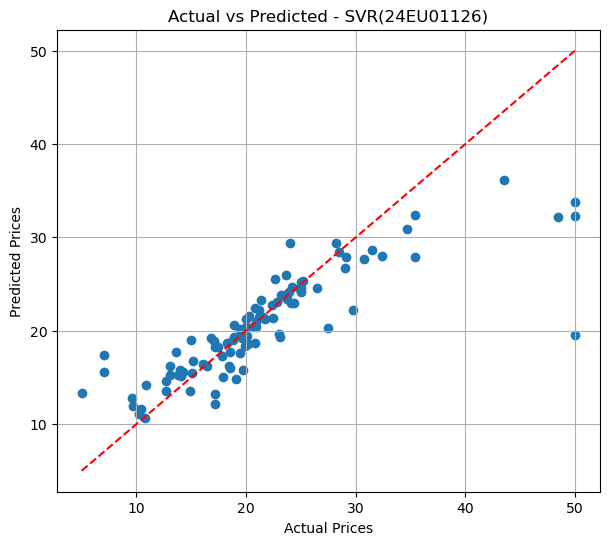

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

url="https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
df=pd.read_csv(url)

X=df.drop("medv",axis=1)
y=df["medv"]

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

model=make_pipeline(StandardScaler(),SVR(kernel='rbf'))
model.fit(X_train,y_train)

pred=model.predict(X_test)

plt.figure(figsize=(7,6))
plt.scatter(y_test,pred)
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],'r--')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted - SVR(24EU01126)")
plt.grid(True)
plt.show()


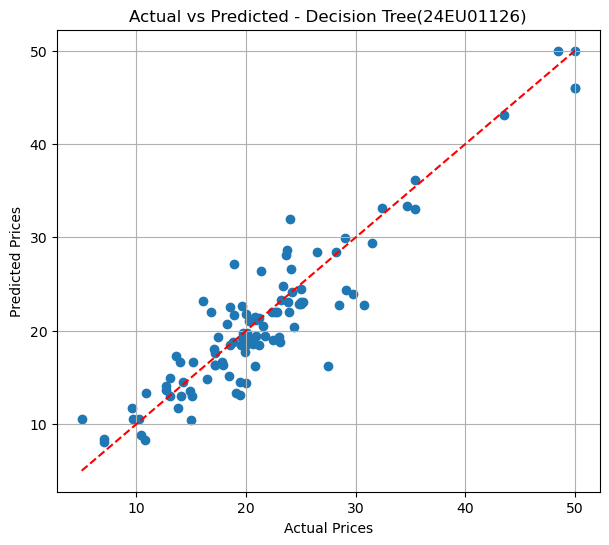

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

url="https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
df=pd.read_csv(url)

X=df.drop("medv",axis=1)
y=df["medv"]

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

model=DecisionTreeRegressor(random_state=42)
model.fit(X_train,y_train)

pred=model.predict(X_test)

plt.figure(figsize=(7,6))
plt.scatter(y_test,pred)
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],'r--')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted - Decision Tree(24EU01126)")
plt.grid(True)
plt.show()